# Pipeline IA — Classification Fake vs Real 

---
## ÉTAPE 1 — Chargement et Préparation

In [2]:
import pandas as pd
import numpy as np
import random
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

le_final = LabelEncoder()
le_final.fit(['fake', 'real'])
print(f'LabelEncoder : fake={le_final.transform(["fake"])[0]}, real={le_final.transform(["real"])[0]}')

df_raw = pd.read_csv('datasets/clean_pages.csv')
df_raw['clean_text'] = df_raw['clean_text'].fillna('').astype(str)
df_raw['label']      = df_raw['label'].astype(str).str.strip()

df_labeled   = df_raw[df_raw['label'].isin(['fake', 'real'])].copy()
df_unlabeled = df_raw[~df_raw['label'].isin(['fake', 'real'])].copy()
df_fake      = df_raw[df_raw['label'] == 'fake'].copy()
df_real      = df_raw[df_raw['label'] == 'real'].copy()

print('=' * 55)
print('DATASET ORIGINAL')
print('=' * 55)
print(f'Total pages       : {len(df_raw)}')
print(f'Labelisés         : {len(df_labeled)} (fake={len(df_fake)}, real={len(df_real)})')
print(f'Non-labelisés NaN : {len(df_unlabeled)}')
ratio = len(df_real) / max(len(df_fake), 1)
print(f'Ratio real/fake   = {ratio:.1f}x')

LabelEncoder : fake=0, real=1
DATASET ORIGINAL
Total pages       : 1840
Labelisés         : 1736 (fake=118, real=1618)
Non-labelisés NaN : 104
Ratio real/fake   = 13.7x


---
## ÉTAPE 2 — Split 

In [3]:


df_labeled_reset = df_labeled.reset_index(drop=True)
y_labeled = le_final.transform(df_labeled_reset['label'])

idx_train, idx_test = train_test_split(
    df_labeled_reset.index,
    test_size=0.20,
    stratify=y_labeled,
    random_state=42
)

df_train_orig = df_labeled_reset.loc[idx_train].copy().reset_index(drop=True)
df_test       = df_labeled_reset.loc[idx_test].copy().reset_index(drop=True)

X_test_final = df_test['clean_text'].tolist()
y_test_final = df_test['label'].tolist()
y_test_enc   = le_final.transform(y_test_final)

print('=' * 60)
print('SPLIT STRATIFIÉ ')
print('=' * 60)
print(f'Train original : {len(df_train_orig)} (fake={( df_train_orig.label=="fake").sum()}, real={(df_train_orig.label=="real").sum()})')
print(f'Test           : {len(df_test)}  (fake={(df_test.label=="fake").sum()}, real={(df_test.label=="real").sum()})')
print('✅ Test set = données originales, jamais augmentées')
print('✅ Ratio 20% uniforme pour fake ET real')

SPLIT STRATIFIÉ 
Train original : 1388 (fake=94, real=1294)
Test           : 348  (fake=24, real=324)
✅ Test set = données originales, jamais augmentées
✅ Ratio 20% uniforme pour fake ET real


---
## 🔬 ÉTAPE 3 — Semi-Supervisé : Labels NaN

>

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

tfidf_semi = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_semi     = tfidf_semi.fit_transform(df_train_orig['clean_text'])
y_semi     = le_final.transform(df_train_orig['label'])

lr_semi = LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced')
lr_semi.fit(X_semi, y_semi)

X_unlab      = tfidf_semi.transform(df_unlabeled['clean_text'].fillna('').astype(str))
preds_enc    = lr_semi.predict(X_unlab)
preds_unlab  = le_final.inverse_transform(preds_enc)
proba_unlab  = lr_semi.predict_proba(X_unlab).max(axis=1)

df_unlabeled = df_unlabeled.copy()
df_unlabeled['label']        = preds_unlab
df_unlabeled['label_proba']  = proba_unlab
df_unlabeled['label_source'] = 'predicted'

CONFIDENCE_THRESHOLD = 0.75  # Seuil relevé (v5 = 0.70)
df_unlabeled_confident = df_unlabeled[df_unlabeled['label_proba'] >= CONFIDENCE_THRESHOLD].copy()
df_unlabeled_rejected  = df_unlabeled[df_unlabeled['label_proba'] <  CONFIDENCE_THRESHOLD].copy()

print('=' * 60)
print('SEMI-SUPERVISÉ ')
print('=' * 60)
print(f'Fitté sur df_train_orig (pas df_labeled complet)')
print(f'Seuil de confiance : {CONFIDENCE_THRESHOLD} (relevé vs 0.70 en v5)')
print(f'Prédictions acceptées : {len(df_unlabeled_confident)}')
print(f'Prédictions rejetées  : {len(df_unlabeled_rejected)}')
print(f'Confiance moyenne     : {df_unlabeled_confident["label_proba"].mean():.3f}')
print()
print('Distribution des labels prédits (acceptés) :')
print(df_unlabeled_confident['label'].value_counts().to_string())

SEMI-SUPERVISÉ 
Fitté sur df_train_orig (pas df_labeled complet)
Seuil de confiance : 0.75 (relevé vs 0.70 en v5)
Prédictions acceptées : 92
Prédictions rejetées  : 12
Confiance moyenne     : 0.906

Distribution des labels prédits (acceptés) :
label
real    86
fake     6


---
## 🔁 ÉTAPE 4 — Augmentation de Données (sur TRAIN uniquement)

> *

In [5]:
# ============================================================
# Technique 1 : Synonymes manuels
# FIX v6 : appliqué sur df_train_orig uniquement
# ============================================================
synonymes = {
    'government':  ['authorities', 'administration', 'regime', 'state', 'officials'],
    'war':         ['conflict', 'battle', 'military operation', 'combat', 'fighting'],
    'attack':      ['strike', 'assault', 'offensive', 'raid', 'bombardment'],
    'claim':       ['allege', 'assert', 'declare', 'insist', 'state'],
    'secret':      ['hidden', 'classified', 'covert', 'undisclosed', 'concealed'],
    'control':     ['dominate', 'manipulate', 'oversee', 'command', 'rule'],
    'media':       ['press', 'news outlets', 'journalists', 'reporters', 'propaganda'],
    'russia':      ['moscow', 'kremlin', 'russian forces', 'russian military'],
    'ukraine':     ['kiev', 'ukrainian forces', 'zelensky government'],
    'nato':        ['western alliance', 'western powers', 'atlantic alliance'],
    'conspiracy':  ['plot', 'scheme', 'agenda', 'plan', 'operation'],
    'reveal':      ['expose', 'uncover', 'disclose', 'leak', 'show'],
    'dangerous':   ['threatening', 'deadly', 'lethal', 'hazardous', 'alarming'],
    'fake':        ['false', 'fabricated', 'invented', 'manufactured', 'fraudulent'],
}

def augment_synonyms(text, n=4):  
    results = []
    words = text.split()
    for _ in range(n):
        new_words = [
            random.choice(synonymes[w.lower()])
            if w.lower() in synonymes and random.random() < 0.3
            else w
            for w in words
        ]
        results.append(' '.join(new_words))
    return results

# Augmenter uniquement les fakes du TRAIN
df_fake_train = df_train_orig[df_train_orig['label'] == 'fake']

print('Génération par synonymes (sur train uniquement)...')
syn_texts = []
for text in df_fake_train['clean_text']:
    syn_texts.extend(augment_synonyms(text, n=4))
print(f'✅ Textes générés par synonymes : {len(syn_texts)}')

Génération par synonymes (sur train uniquement)...
✅ Textes générés par synonymes : 376


In [6]:
# ============================================================
# Technique 2 : Back-translation
# FIX v6 : appliqué sur df_fake_train uniquement
# ============================================================
from deep_translator import GoogleTranslator

def back_translate(text, max_chars=400):
    try:
        text_short = text[:max_chars]
        fr         = GoogleTranslator(source='en', target='fr').translate(text_short)
        time.sleep(0.5)
        back       = GoogleTranslator(source='fr', target='en').translate(fr)
        return back
    except:
        return None

print('Génération par back-translation (patience ~1 min)...')
bt_texts = []
for text in df_fake_train['clean_text']:
    for _ in range(3):  # FIX v6 : 3 au lieu de 5
        result = back_translate(text)
        if result:
            bt_texts.append(result)
print(f'✅ Textes générés par back-translation : {len(bt_texts)}')

Génération par back-translation (patience ~1 min)...
✅ Textes générés par back-translation : 282


In [7]:
# ============================================================
# Assembler le dataset d'entraînement final
# ============================================================
all_augmented = syn_texts + bt_texts

df_aug_new = pd.DataFrame({
    'clean_text':   all_augmented,
    'label':        'fake',
    'label_source': 'augmented'
})
df_aug_new = df_aug_new[df_aug_new['clean_text'].str.len() > 50].dropna()

df_train_orig['label_source'] = 'original'
df_unlabeled_confident['label_source'] = 'predicted'

# Train = original train + pseudo-labels confiants + augmentation
df_train_final = pd.concat(
    [df_train_orig, df_unlabeled_confident[['clean_text', 'label', 'label_source']], df_aug_new],
    ignore_index=True
).sample(frac=1, random_state=42).reset_index(drop=True)

df_train_final.to_csv('datasets/clean_pages_augmented_v6.csv', index=False)

X_train_final = df_train_final['clean_text'].tolist()
y_train_final = df_train_final['label'].tolist()
y_train_enc   = le_final.transform(y_train_final)

print('=' * 60)
print('DATASET ENTRAÎNEMENT FINAL ')
print('=' * 60)
print(f'Train : {len(y_train_final)} (fake={y_train_final.count("fake")}, real={y_train_final.count("real")})')
print(f'Test  : {len(y_test_final)}  (fake={y_test_final.count("fake")}, real={y_test_final.count("real")})')
print()
print('✅ Augmentation appliquée APRÈS split → test set propre')
print('✅ Semi-supervisé fitté sur train uniquement')
print('✅ Sauvegardé : datasets/clean_pages_augmented_v6.csv')

DATASET ENTRAÎNEMENT FINAL 
Train : 2138 (fake=758, real=1380)
Test  : 348  (fake=24, real=324)

✅ Augmentation appliquée APRÈS split → test set propre
✅ Semi-supervisé fitté sur train uniquement
✅ Sauvegardé : datasets/clean_pages_augmented_v6.csv


---
## 🛡️ ÉTAPE 5 — TF-IDF (fit sur train uniquement)

In [8]:
tfidf_final = TfidfVectorizer(
    max_features=3000, ngram_range=(1, 2), min_df=2, max_df=0.95
)
X_train_enc = tfidf_final.fit_transform(X_train_final)   # fit sur train ✅
X_test_enc  = tfidf_final.transform(X_test_final)        # transform seulement ✅

print(f'TF-IDF features : {X_train_enc.shape[1]}')
print(f'Train shape     : {X_train_enc.shape}')
print(f'Test shape      : {X_test_enc.shape}')
print('✅ tfidf_final fitté sur train uniquement')

TF-IDF features : 3000
Train shape     : (2138, 3000)
Test shape      : (348, 3000)
✅ tfidf_final fitté sur train uniquement


---
## 🔍 ÉTAPE 6 — Cross-Validation avec seuil strict anti-overfitting

> 

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline

# FIX v6 : CV sur df_train_orig (données originales du train uniquement)
y_cv_enc = le_final.transform(df_train_orig['label'].tolist())

cv_5fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

candidates = {
    'LogReg': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=2, max_df=0.95)),
        ('clf',   LogisticRegression(max_iter=2000, class_weight='balanced', C=0.8, solver='liblinear'))
    ]),
    'RandomForest': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=2, max_df=0.95)),
        ('clf',   RandomForestClassifier(
            n_estimators=400, max_depth=10, min_samples_split=10,
            min_samples_leaf=5, max_features='sqrt',
            class_weight='balanced', random_state=42
        ))
    ])
}

OVERFIT_THRESHOLD = 0.08  
cv_selection = {}
print('=' * 75)
print(f'SÉLECTION — CROSS-VALIDATION 5-FOLD (seuil gap = {OVERFIT_THRESHOLD})')
print('=' * 75)
print(f'{"Candidat":<20} | {"Train F1":>8} | {"Test F1":>8} | {"Gap":>6} | Status')
print('-' * 75)

for name, pipeline in candidates.items():
    scores = cross_validate(
        pipeline, df_train_orig['clean_text'], y_cv_enc,
        cv=cv_5fold, scoring='f1_macro', return_train_score=True
    )
    train_f1 = scores['train_score'].mean()
    test_f1  = scores['test_score'].mean()
    gap      = train_f1 - test_f1
    status   = '🚫 REJETÉ (overfit)' if gap > OVERFIT_THRESHOLD else '✅ ok'
    cv_selection[name] = {
        'Train F1': round(train_f1, 4),
        'Test F1':  round(test_f1, 4),
        'Gap':      round(gap, 4),
        'Status':   status
    }
    print(f'{name:<20} | {train_f1:>8.4f} | {test_f1:>8.4f} | {gap:>6.4f} | {status}')

df_cv_sel = pd.DataFrame(cv_selection).T
valid_models = df_cv_sel[~df_cv_sel['Status'].str.contains('REJETÉ')]

if len(valid_models) == 0:
    print('\n⚠️  Tous les modèles sont en overfit. Révise les hyperparamètres.')
else:
    best_cand = valid_models['Test F1'].astype(float).idxmax()
    print(f'\n🏆 MEILLEUR CANDIDAT VALIDE : {best_cand}')
    print(f'   F1 CV = {df_cv_sel.loc[best_cand, "Test F1"]}')

SÉLECTION — CROSS-VALIDATION 5-FOLD (seuil gap = 0.08)
Candidat             | Train F1 |  Test F1 |    Gap | Status
---------------------------------------------------------------------------
LogReg               |   0.8591 |   0.8096 | 0.0496 | ✅ ok
RandomForest         |   0.8966 |   0.8323 | 0.0643 | ✅ ok

🏆 MEILLEUR CANDIDAT VALIDE : RandomForest
   F1 CV = 0.8323


---
##  ÉTAPE 7 — Entraînement Final des 3 Modèles ML



In [10]:
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    f1_score,
    roc_auc_score
)

sample_weights = compute_sample_weight('balanced', y_train_enc)

final_models = {

    'LogReg': LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        C=0.1
    ),

    'RandomForest': RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        max_depth=5,
        min_samples_leaf=5,
        random_state=42
    ),

    'HistGradientBoosting': HistGradientBoostingClassifier(
        max_iter=100,
        learning_rate=0.05,
        max_depth=2,
        random_state=42
    )
}

final_preds  = {}
final_fitted = {}
final_probas = {}

for name, model in final_models.items():

    if name == 'HistGradientBoosting':

        X_train_model = X_train_enc.toarray()
        X_test_model  = X_test_enc.toarray()

        model.fit(
            X_train_model,
            y_train_enc,
            sample_weight=sample_weights
        )

    else:

        X_train_model = X_train_enc
        X_test_model  = X_test_enc

        model.fit(X_train_model, y_train_enc)

    y_pred  = model.predict(X_test_model)
    y_proba = model.predict_proba(X_test_model)[:, 1]

    final_preds[name]  = y_pred
    final_fitted[name] = model
    final_probas[name] = y_proba

    print('=' * 60)
    print(f'MODELE : {name}')
    print('=' * 60)

    print(f'Accuracy  : {accuracy_score(y_test_enc, y_pred):.4f}')
    print(f'F1-macro  : {f1_score(y_test_enc, y_pred, average="macro"):.4f}')
    print(f'ROC-AUC   : {roc_auc_score(y_test_enc, y_proba):.4f}')

    print()

    print(classification_report(
        y_test_enc,
        y_pred,
        target_names=le_final.classes_
    ))

MODELE : LogReg
Accuracy  : 0.9109
F1-macro  : 0.7628
ROC-AUC   : 0.9501

              precision    recall  f1-score   support

        fake       0.43      0.88      0.58        24
        real       0.99      0.91      0.95       324

    accuracy                           0.91       348
   macro avg       0.71      0.89      0.76       348
weighted avg       0.95      0.91      0.92       348

MODELE : RandomForest
Accuracy  : 0.9397
F1-macro  : 0.8113
ROC-AUC   : 0.9424

              precision    recall  f1-score   support

        fake       0.54      0.83      0.66        24
        real       0.99      0.95      0.97       324

    accuracy                           0.94       348
   macro avg       0.76      0.89      0.81       348
weighted avg       0.96      0.94      0.95       348

MODELE : HistGradientBoosting
Accuracy  : 0.9626
F1-macro  : 0.8573
ROC-AUC   : 0.9403

              precision    recall  f1-score   support

        fake       0.72      0.75      0.73      

---
##  ÉTAPE 8 — BERT / Sentence Transformers

In [11]:
from sentence_transformers import SentenceTransformer

print('Chargement du modèle BERT...')
bert_model = SentenceTransformer('paraphrase-MiniLM-L6-v2')
print('✅ Modèle BERT chargé')

print('\nEncodage des textes (train)...')
X_train_bert = bert_model.encode(
    X_train_final, batch_size=64, show_progress_bar=True, convert_to_numpy=True
)

print('\nEncodage des textes (test)...')
X_test_bert = bert_model.encode(
    X_test_final, batch_size=64, show_progress_bar=True, convert_to_numpy=True
)

print(f'\n✅ Train : {X_train_bert.shape}  |  Test : {X_test_bert.shape}')

Chargement du modèle BERT...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5150.80it/s]


✅ Modèle BERT chargé

Encodage des textes (train)...


Batches: 100%|██████████| 34/34 [01:27<00:00,  2.58s/it]



Encodage des textes (test)...


Batches: 100%|██████████| 6/6 [00:12<00:00,  2.02s/it]


✅ Train : (2138, 384)  |  Test : (348, 384)


In [12]:
bert_classifier = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    C=1.0,
    solver='lbfgs'
)

bert_classifier.fit(X_train_bert, y_train_enc)

y_pred_bert  = bert_classifier.predict(X_test_bert)
y_proba_bert = bert_classifier.predict_proba(X_test_bert)[:, 1]

print('=' * 60)
print('RÉSULTATS — BERT + LogReg')
print('=' * 60)

print(f'Accuracy : {accuracy_score(y_test_enc, y_pred_bert):.4f}')
print(f'F1-macro : {f1_score(y_test_enc, y_pred_bert, average="macro"):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test_enc, y_proba_bert):.4f}')

print()

print(classification_report(
    y_test_enc,
    y_pred_bert,
    target_names=le_final.classes_
))

final_preds['BERT']  = y_pred_bert
final_probas['BERT'] = y_proba_bert

RÉSULTATS — BERT + LogReg
Accuracy : 0.9224
F1-macro : 0.7420
ROC-AUC  : 0.8686

              precision    recall  f1-score   support

        fake       0.45      0.62      0.53        24
        real       0.97      0.94      0.96       324

    accuracy                           0.92       348
   macro avg       0.71      0.78      0.74       348
weighted avg       0.94      0.92      0.93       348



In [12]:
from sklearn.metrics.pairwise import cosine_similarity

propaganda_profile = [
    "This is fake news and propaganda spread by western media to manipulate public opinion."
    " The truth is being hidden. Government lies and conspiracies against the people."
    " Secret agenda, disinformation campaign, false flag operation."
]
neutral_profile = [
    "According to official sources, the report confirms the findings."
    " Independent journalists verified the facts. Multiple sources corroborate the information."
]

prop_vec    = bert_model.encode(propaganda_profile)
neutral_vec = bert_model.encode(neutral_profile)


df_model = df_train_final.copy()

print('Encodage du dataset complet pour similarité sémantique...')
X_all_bert = bert_model.encode(
    df_model['clean_text'].fillna('').astype(str).tolist(),
    batch_size=64, show_progress_bar=True, convert_to_numpy=True
)

df_model['propaganda_similarity'] = cosine_similarity(X_all_bert, prop_vec).ravel().round(4)
df_model['neutral_similarity']    = cosine_similarity(X_all_bert, neutral_vec).ravel().round(4)

print('\n✅ Scores de similarité calculés')
print(df_model.groupby('label')[['propaganda_similarity', 'neutral_similarity']].mean().round(3))

Encodage du dataset complet pour similarité sémantique...


Batches: 100%|██████████| 34/34 [01:28<00:00,  2.59s/it]


✅ Scores de similarité calculés
       propaganda_similarity  neutral_similarity
label                                           
fake                   0.125               0.126
real                   0.117               0.078


---
##  ÉTAPE 9 — Comparaison Honnête : ML Classique vs BERT

> 

In [13]:
from sklearn.model_selection import cross_validate, StratifiedKFold

skf_honest = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


print('Encodage BERT du train original (pour cross-val honnête)...')
X_orig_bert = bert_model.encode(
    df_train_orig['clean_text'].fillna('').astype(str).tolist(),
    batch_size=64, show_progress_bar=True, convert_to_numpy=True
)
y_cv_enc = le_final.transform(df_train_orig['label'].tolist())

cv_bert_honest = cross_validate(
    LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0),
    X_orig_bert, y_cv_enc,
    cv=skf_honest, scoring=['f1_macro', 'roc_auc'], return_train_score=True
)

cv_logreg_honest = cross_validate(
    Pipeline([
        ('tfidf', TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=2, max_df=0.95)),
        ('clf',   LogisticRegression(max_iter=1000, class_weight='balanced', C=0.1))
    ]),
    df_train_orig['clean_text'].fillna('').astype(str),
    y_cv_enc,
    cv=skf_honest, scoring=['f1_macro', 'roc_auc'], return_train_score=True
)

print('=' * 70)
print('ÉVALUATION — CROSS-VALIDATION ')
print('(sur données originales du train, sans augmentation)')
print('=' * 70)
print(f'{"Modèle":<25} | {"F1-macro":>10} | {"± std":>8} | {"ROC-AUC":>10} | {"± std":>8} | Gap')
print('-' * 75)

for label, cv_res in [('TF-IDF + LogReg', cv_logreg_honest), ('BERT + LogReg', cv_bert_honest)]:
    f1_mean   = cv_res['test_f1_macro'].mean()
    f1_std    = cv_res['test_f1_macro'].std()
    auc_mean  = cv_res['test_roc_auc'].mean()
    auc_std   = cv_res['test_roc_auc'].std()
    train_f1  = cv_res['train_f1_macro'].mean()
    gap       = train_f1 - f1_mean
    gap_flag  = '🚫 overfit' if gap > 0.08 else '✅'
    print(f'{label:<25} | {f1_mean:>10.4f} | {f1_std:>8.4f} | {auc_mean:>10.4f} | {auc_std:>8.4f} | {gap:.4f} {gap_flag}')

print()
print('→ Ces valeurs sont défendables devant le jury')

Encodage BERT du train original (pour cross-val honnête)...


Batches: 100%|██████████| 22/22 [00:57<00:00,  2.60s/it]


ÉVALUATION — CROSS-VALIDATION 
(sur données originales du train, sans augmentation)
Modèle                    |   F1-macro |    ± std |    ROC-AUC |    ± std | Gap
---------------------------------------------------------------------------
TF-IDF + LogReg           |     0.7768 |   0.0396 |     0.9685 |   0.0193 | 0.0199 ✅
BERT + LogReg             |     0.7362 |   0.0316 |     0.9303 |   0.0376 | 0.1505 🚫 overfit

→ Ces valeurs sont défendables devant le jury


In [14]:
all_models_results = {}

for name, y_pred in final_preds.items():
    y_proba = final_probas[name]
    all_models_results[name] = {
        'Accuracy': round(accuracy_score(y_test_enc, y_pred), 4),
        'F1-fake':  round(f1_score(y_test_enc, y_pred, pos_label=0), 4),
        'F1-real':  round(f1_score(y_test_enc, y_pred, pos_label=1), 4),
        'F1-macro': round(f1_score(y_test_enc, y_pred, average='macro'), 4),
        'ROC-AUC':  round(roc_auc_score(y_test_enc, y_proba), 4),
    }

df_all_results = pd.DataFrame(all_models_results).T

print('=' * 75)
print('COMPARAISON FINALE  ')
print('=' * 75)
print(f'Test set : {y_test_final.count("fake")} fake / {y_test_final.count("real")} real')
print()
print(df_all_results.to_string())

best_model = df_all_results['F1-macro'].astype(float).idxmax()
print(f'\n🏆 Meilleur modèle (F1-macro) : {best_model}')
print(f'   F1-macro = {df_all_results.loc[best_model, "F1-macro"]}')
print(f'   Accuracy = {df_all_results.loc[best_model, "Accuracy"]}')

COMPARAISON FINALE  
Test set : 24 fake / 324 real

                      Accuracy  F1-fake  F1-real  F1-macro  ROC-AUC
LogReg                  0.9109   0.5753   0.9502    0.7628   0.9502
RandomForest            0.9454   0.6780   0.9702    0.8241   0.9380
HistGradientBoosting    0.9598   0.7200   0.9783    0.8492   0.9358
BERT                    0.9224   0.5263   0.9577    0.7420   0.8687

🏆 Meilleur modèle (F1-macro) : HistGradientBoosting
   F1-macro = 0.8492
   Accuracy = 0.9598


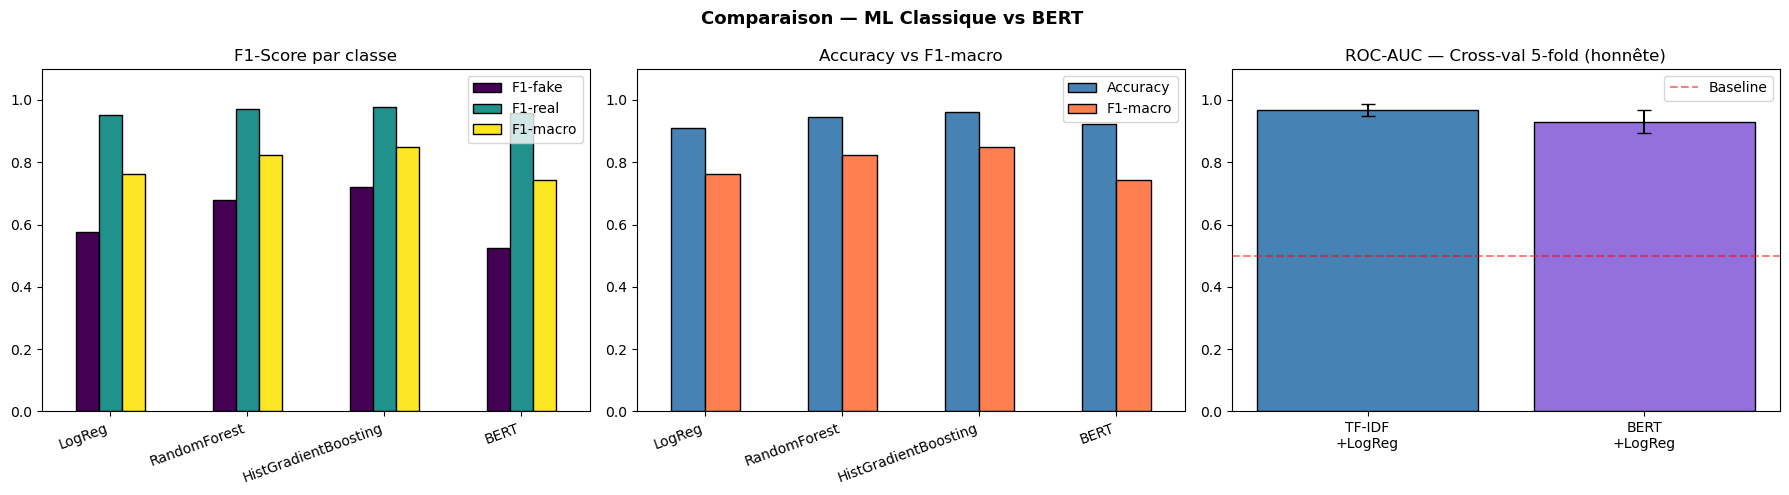

✅ Sauvegardé : datasets/comparaison_finale.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df_all_results[['F1-fake', 'F1-real', 'F1-macro']].astype(float).plot(
    kind='bar', ax=axes[0], colormap='viridis', edgecolor='black')
axes[0].set_title('F1-Score par classe')
axes[0].set_ylim(0, 1.1)
axes[0].set_xticklabels(df_all_results.index, rotation=20, ha='right')

df_all_results[['Accuracy', 'F1-macro']].astype(float).plot(
    kind='bar', ax=axes[1], color=['steelblue', 'coral'], edgecolor='black')
axes[1].set_title('Accuracy vs F1-macro')
axes[1].set_ylim(0, 1.1)
axes[1].set_xticklabels(df_all_results.index, rotation=20, ha='right')

cv_roc_means = [
    cv_logreg_honest['test_roc_auc'].mean(),
    cv_bert_honest['test_roc_auc'].mean(),
]
cv_roc_stds = [
    cv_logreg_honest['test_roc_auc'].std(),
    cv_bert_honest['test_roc_auc'].std(),
]
axes[2].bar(['TF-IDF\n+LogReg', 'BERT\n+LogReg'],
            cv_roc_means, yerr=cv_roc_stds,
            color=['steelblue', 'mediumpurple'], edgecolor='black', capsize=5)
axes[2].set_title('ROC-AUC — Cross-val 5-fold (honnête)')
axes[2].set_ylim(0, 1.1)
axes[2].axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Baseline')
axes[2].legend()

plt.suptitle('Comparaison — ML Classique vs BERT ', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('datasets/comparaison_finale.png', dpi=150)
plt.show()
print('✅ Sauvegardé : datasets/comparaison_finale.png')

---
## 🎯ÉTAPE 10 — Analyse de Stance (Polarisation)

ANALYSE DE STANCE — DISTRIBUTION GLOBALE
stance
neutral       1839
pro_russia     288
pro_west        11


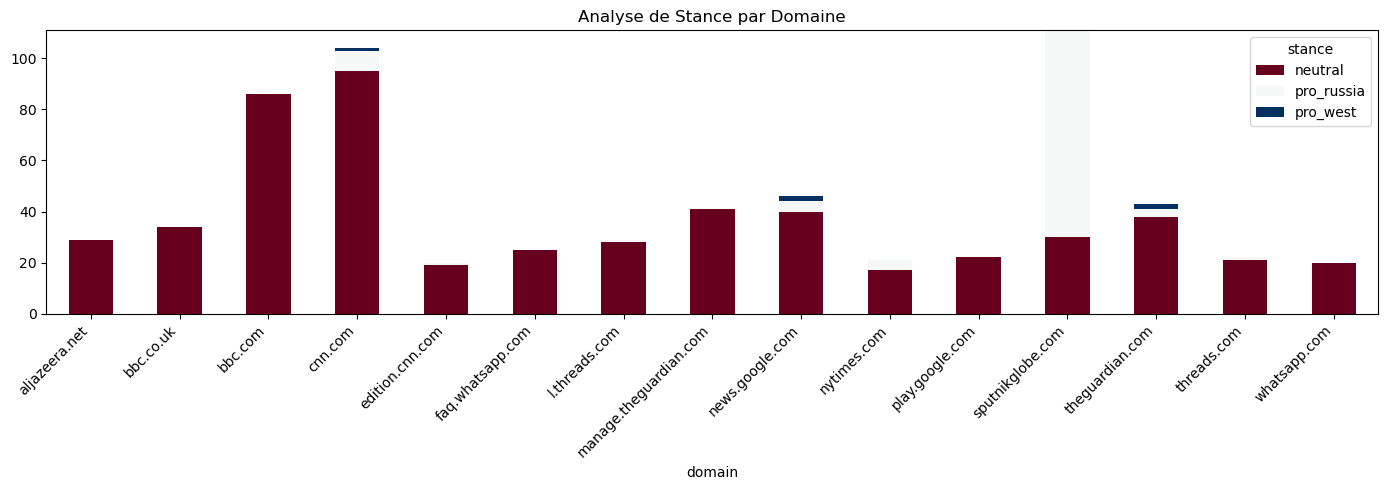

In [16]:
pro_russia = ['russia', 'russian', 'kremlin', 'putin', 'moscow',
              'special operation', 'denazification', 'nato aggression']
pro_west   = ['democracy', 'freedom', 'sanctions', 'invasion', 'war crime',
              'human rights', 'nato allies', 'ukraine sovereignty']

def get_stance(text):
    if not isinstance(text, str): return 'neutral'
    t        = text.lower()
    score_ru = sum(1 for w in pro_russia if w in t)
    score_we = sum(1 for w in pro_west   if w in t)
    if   score_ru > score_we + 1: return 'pro_russia'
    elif score_we > score_ru + 1: return 'pro_west'
    else:                         return 'neutral'

df_model['stance'] = df_model['clean_text'].apply(get_stance)

print('=' * 55)
print('ANALYSE DE STANCE — DISTRIBUTION GLOBALE')
print('=' * 55)
print(df_model['stance'].value_counts().to_string())

if 'domain' in df_model.columns:
    top_domains = df_model['domain'].value_counts().head(15).index
    df_top      = df_model[df_model['domain'].isin(top_domains)]
    stance_dist = df_top.groupby(['domain', 'stance']).size().unstack(fill_value=0)
    stance_dist.plot(kind='bar', stacked=True, figsize=(14, 5), colormap='RdBu')
    plt.title('Analyse de Stance par Domaine')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('datasets/stance_analysis.png', dpi=120)
    plt.show()

---
## ✍️ ÉTAPE 11 — Stylométrie

STYLOMÉTRIE — FAKE vs REAL
       avg_word_len  vocab_richness  text_length
label                                           
fake          6.455           0.611      307.499
real          5.824           0.594      319.205


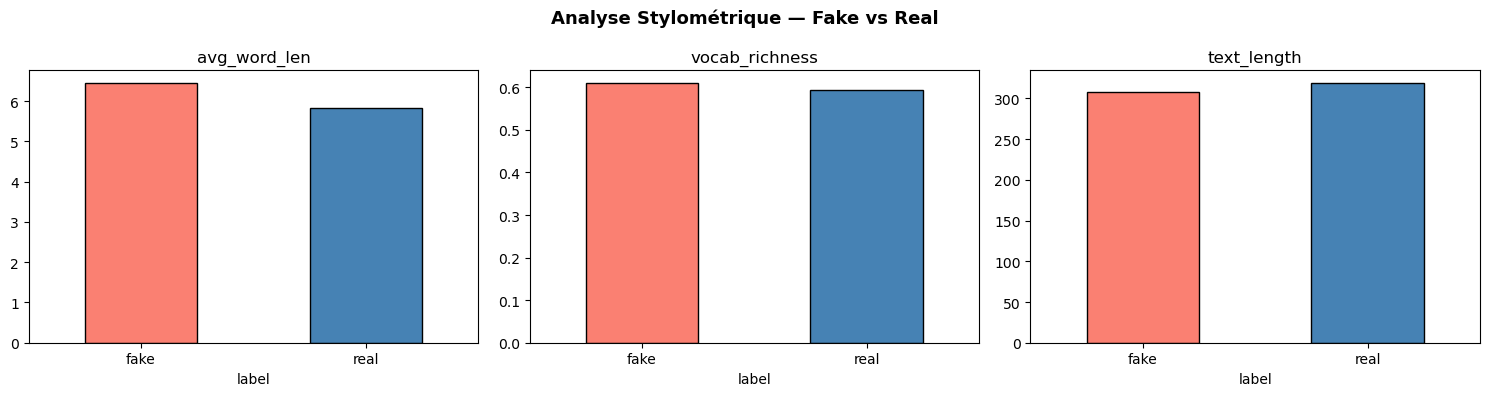

In [17]:
def stylometric_features(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return pd.Series({'avg_word_len': 0, 'vocab_richness': 0, 'text_length': 0})
    words          = text.split()
    avg_word_len   = np.mean([len(w) for w in words]) if words else 0
    vocab_richness = len(set(words)) / len(words)      if words else 0
    text_length    = len(words)
    return pd.Series({
        'avg_word_len':   round(avg_word_len, 2),
        'vocab_richness': round(vocab_richness, 3),
        'text_length':    text_length
    })

stylo    = df_model['clean_text'].apply(stylometric_features)
df_model = pd.concat([df_model, stylo], axis=1)

print('STYLOMÉTRIE — FAKE vs REAL')
print(df_model.groupby('label')[['avg_word_len', 'vocab_richness', 'text_length']].mean().round(3).to_string())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(['avg_word_len', 'vocab_richness', 'text_length']):
    df_model.groupby('label')[col].mean().plot(
        kind='bar', ax=axes[i], color=['salmon', 'steelblue'], edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xticklabels(['fake', 'real'], rotation=0)
plt.suptitle('Analyse Stylométrique — Fake vs Real', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('datasets/stylometrie.png', dpi=120)
plt.show()

---
##  ÉTAPE 12 — Sauvegarde du Meilleur Modèle

In [18]:
import joblib
import os
os.makedirs('datasets', exist_ok=True)

best_file = best_model.lower().replace(' ', '_')

if best_model == 'BERT':
    joblib.dump(bert_classifier, 'datasets/best_model_bert_classifier.pkl')
    bert_model.save('datasets/bert_model_local')
    joblib.dump(le_final, 'datasets/label_encoder.pkl')
    print('✅ Classifieur BERT : datasets/best_model_bert_classifier.pkl')
    print('✅ Modèle BERT      : datasets/bert_model_local/')
else:
    joblib.dump(final_fitted[best_model], f'datasets/best_model_{best_file}.pkl')
    joblib.dump(tfidf_final, 'datasets/tfidf_final.pkl')
    joblib.dump(le_final, 'datasets/label_encoder.pkl')
    print(f'✅ Modèle : datasets/best_model_{best_file}.pkl')
    print(f'✅ TF-IDF : datasets/tfidf_final.pkl')

print('✅ LabelEncoder : datasets/label_encoder.pkl')

# Prédictions sur le train set
texts_train = df_model['clean_text'].fillna('').astype(str).tolist()

if best_model == 'BERT':
    preds_all = bert_classifier.predict(X_all_bert)
    proba_all = bert_classifier.predict_proba(X_all_bert).max(axis=1)
else:
    X_all = tfidf_final.transform(texts_train).toarray()
    preds_all = final_fitted[best_model].predict(X_all)
    proba_all = final_fitted[best_model].predict_proba(X_all).max(axis=1)

df_model['predicted_label']        = le_final.inverse_transform(preds_all)
df_model['prediction_confidence']  = proba_all.round(4)

cols_exist = [c for c in ['url', 'domain', 'label', 'predicted_label',
                            'prediction_confidence', 'label_source'] if c in df_model.columns]
df_model[cols_exist].to_csv('datasets/predictions_finales.csv', index=False)
print('✅ Prédictions : datasets/predictions_finales.csv')

✅ Modèle : datasets/best_model_histgradientboosting.pkl
✅ TF-IDF : datasets/tfidf_final.pkl
✅ LabelEncoder : datasets/label_encoder.pkl
✅ Prédictions : datasets/predictions_finales.csv


---
## 📤 ÉTAPE 13 — Export Final pour le Dashboard

In [19]:
cols_dashboard = [
    'url', 'domain', 'label', 'predicted_label',
    'prediction_confidence', 'stance',
    'avg_word_len', 'vocab_richness', 'text_length',
    'propaganda_similarity', 'neutral_similarity',
    'label_source'
]
cols_exist   = [c for c in cols_dashboard if c in df_model.columns]
df_dashboard = df_model[cols_exist].copy()
df_dashboard.to_csv('datasets/dashboard_data.csv', index=False)
df_all_results.to_csv('datasets/comparaison_modeles.csv')

# Exemples de prédictions
df_examples = pd.DataFrame({
    'texte':        X_test_final,
    'label_reel':   le_final.inverse_transform(y_test_enc),
    'label_predit': le_final.inverse_transform(final_preds[best_model]),
    'confiance':    final_probas[best_model].round(3)
})
df_examples['correct'] = df_examples['label_reel'] == df_examples['label_predit']
df_examples.to_csv('datasets/exemples_predictions.csv', index=False)

print('✅ Export terminé !')
print(f'Shape dashboard : {df_dashboard.shape}')
print()
print('=' * 60)
print('RÉCAPITULATIF FICHIERS GÉNÉRÉS ')
print('=' * 60)
print('📁 datasets/clean_pages_augmented_v6.csv  — Dataset augmenté (train only)')
print('📁 datasets/predictions_finales.csv       — Prédictions modèle')
print('📁 datasets/exemples_predictions.csv      — Exemples corrects/erreurs')
print('📁 datasets/comparaison_modeles.csv       — Tableau comparatif')
print('📁 datasets/dashboard_data.csv            — Données dashboard')
print('📁 datasets/confusion_*.png               — Matrices de confusion')
print('📁 datasets/comparaison_finale.png        — Graphique comparaison')
print('📁 datasets/stance_analysis.png           — Analyse stance')
print('📁 datasets/stylometrie.png               — Stylométrie')
print(f'📁 datasets/best_model_*.pkl              — Meilleur modèle ({best_model})')



✅ Export terminé !
Shape dashboard : (2138, 12)

RÉCAPITULATIF FICHIERS GÉNÉRÉS 
📁 datasets/clean_pages_augmented_v6.csv  — Dataset augmenté (train only)
📁 datasets/predictions_finales.csv       — Prédictions modèle
📁 datasets/exemples_predictions.csv      — Exemples corrects/erreurs
📁 datasets/comparaison_modeles.csv       — Tableau comparatif
📁 datasets/dashboard_data.csv            — Données dashboard
📁 datasets/confusion_*.png               — Matrices de confusion
📁 datasets/comparaison_finale.png        — Graphique comparaison
📁 datasets/stance_analysis.png           — Analyse stance
📁 datasets/stylometrie.png               — Stylométrie
📁 datasets/best_model_*.pkl              — Meilleur modèle (HistGradientBoosting)
